In [1]:
import pandas as pd
import numpy as np


In [3]:
url = "https://drive.google.com/uc?id=17cbDNBmys04MJqQfrma3jd72VPMnxIq0"
df=pd.read_csv(url)
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [4]:
df.corr()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
RI,1.000000,-0.191885,-0.122274,-0.407326,-0.542052,-0.289833,0.810403,-0.000386,0.143010,-0.164237
Na,-0.191885,1.000000,-0.273732,0.156794,-0.069809,-0.266087,-0.275442,0.326603,-0.241346,0.502898
Mg,-0.122274,-0.273732,1.000000,-0.481799,-0.165927,0.005396,-0.443750,-0.492262,0.083060,-0.744993
Al,-0.407326,0.156794,-0.481799,1.000000,-0.005524,0.325958,-0.259592,0.479404,-0.074402,0.598829
Si,-0.542052,-0.069809,-0.165927,-0.005524,1.000000,-0.193331,-0.208732,-0.102151,-0.094201,0.151565
K,-0.289833,-0.266087,0.005396,0.325958,-0.193331,1.000000,-0.317836,-0.042618,-0.007719,-0.010054
Ca,0.810403,-0.275442,-0.443750,-0.259592,-0.208732,-0.317836,1.000000,-0.112841,0.124968,0.000952
Ba,-0.000386,0.326603,-0.492262,0.479404,-0.102151,-0.042618,-0.112841,1.000000,-0.058692,0.575161
Fe,0.143010,-0.241346,0.083060,-0.074402,-0.094201,-0.007719,0.124968,-0.058692,1.000000,-0.188278
Type,-0.164237,0.502898,-0.744993,0.598829,0.151565,-0.010054,0.000952,0.575161,-0.188278,1.000000


In [5]:
df.drop(columns=['K','Ca'],inplace=True)

In [6]:
df.head()

,RI,Na,Mg,Al,Si,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.0,0.0,1


In [7]:
df.shape

(214, 8)

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df['Type'], test_size=0.2, random_state=42)

In [9]:
X_train.head()

,RI,Na,Mg,Al,Si,Ba,Fe
79,1.51590,12.82,3.52,1.90,72.86,0.00,0.00
161,1.51934,13.64,3.54,0.75,72.65,0.15,0.24
109,1.51818,13.72,0.00,0.56,74.45,0.00,0.00
127,1.52081,13.78,2.28,1.43,71.99,0.00,0.17
95,1.51860,13.36,3.43,1.43,72.26,0.00,0.00


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
X_train_scaled

array([[-0.84623746, -0.74467528,  0.52636164, ...,  0.345884  ,
        -0.33761134, -0.60110996],
       [ 0.28077633,  0.33413832,  0.54088841, ...,  0.07169648,
        -0.04564469,  1.78472688],
       [-0.0992632 ,  0.43938842, -2.03034913, ...,  2.42187517,
        -0.33761134, -0.60110996],
       ...,
       [-0.85278986, -0.34998738,  0.44646443, ...,  0.86814593,
        -0.33761134,  1.28767753],
       [ 0.0121277 ,  0.92617017, -0.43966828, ...,  0.09780958,
        -0.33761134, -0.60110996],
       [-0.09271079, -1.00780055, -0.02565546, ...,  1.58625608,
        -0.33761134,  1.3870874 ]])

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

In [19]:
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=15)

In [20]:
from sklearn.metrics import accuracy_score

y_pred = knn.predict(X_test_scaled)

accuracy_score(y_test, y_pred)

0.6046511627906976

In [21]:
scores = []

for i in range(1,16):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    
    knn.fit(X_train,y_train)
    
    y_pred = knn.predict(X_test)

    scores.append(accuracy_score(y_test, y_pred))

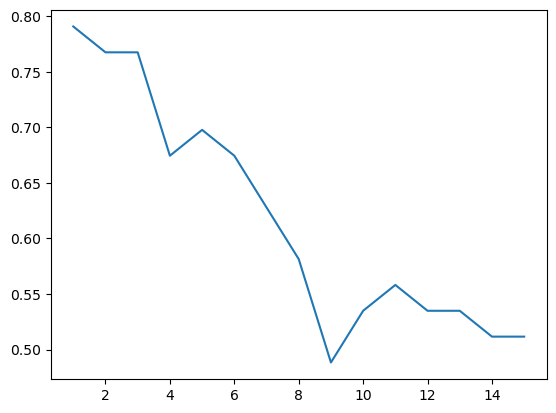

In [22]:
import matplotlib.pyplot as plt

plt.plot(range(1,16),scores)  # 1 neighbour is best

In [23]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(knn, df.iloc[:, :-1], df.iloc[:, -1], cv=5, scoring='accuracy')


In [24]:
scores

array([0.48837209, 0.60465116, 0.55813953, 0.62790698, 0.57142857])